# InsightX AI — 04: Sentiment Analysis

Visualizing review sentiment and its connection to churn, RFM segment, and revenue.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.database.db_connection import get_engine

engine = get_engine()
sentiment = pd.read_sql("SELECT * FROM review_sentiment", engine)
link = pd.read_sql("SELECT * FROM sentiment_business_link", engine)
sentiment.head()

,review_id,customer_id,order_id,rating,review_text,review_date,sentiment_score,sentiment_label,topics,rating_based_sentiment
0,1,1139,806,4,Fast delivery and excellent packaging. Will bu...,2024-07-05,0.5719,Positive,Delivery,Positive
1,2,76,498,1,Delivery was extremely delayed and customer se...,2023-06-01,-0.2944,Negative,"Delivery, Customer Service",Negative
2,3,810,4258,2,"Would not recommend, stopped working within a ...",2023-07-20,-0.1139,Negative,General,Negative
3,4,401,7314,5,"Great quality, exactly as described. Very happ...",2023-03-06,0.8439,Positive,Product Quality,Positive
4,5,7,6873,2,"Poor quality, does not match the description a...",2024-01-01,-0.4767,Negative,Product Quality,Negative


## 1. Overall sentiment distribution

In [ ]:
plt.figure(figsize=(7,5))
sentiment["sentiment_label"].value_counts().plot(kind="bar", color=["seagreen","gray","firebrick"])
plt.title("Review Sentiment Distribution")
plt.ylabel("Number of Reviews")
plt.show()

## 2. Sentiment vs. star rating (validation check)
If VADER is working well, high ratings should cluster in Positive, low ratings in Negative.

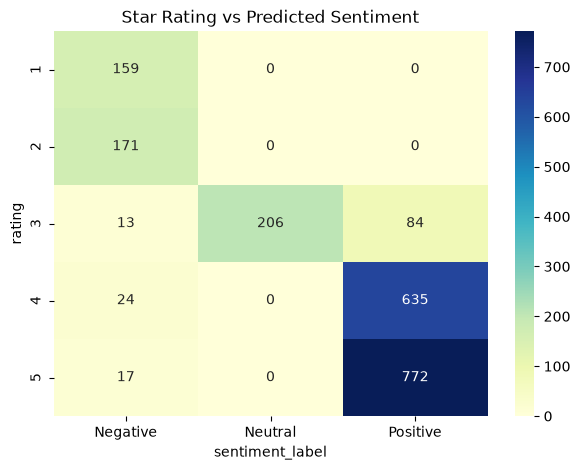

In [2]:
crosstab = pd.crosstab(sentiment["rating"], sentiment["sentiment_label"])
plt.figure(figsize=(7,5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Star Rating vs Predicted Sentiment")
plt.show()

## 3. Most common complaint topics (negative reviews only)

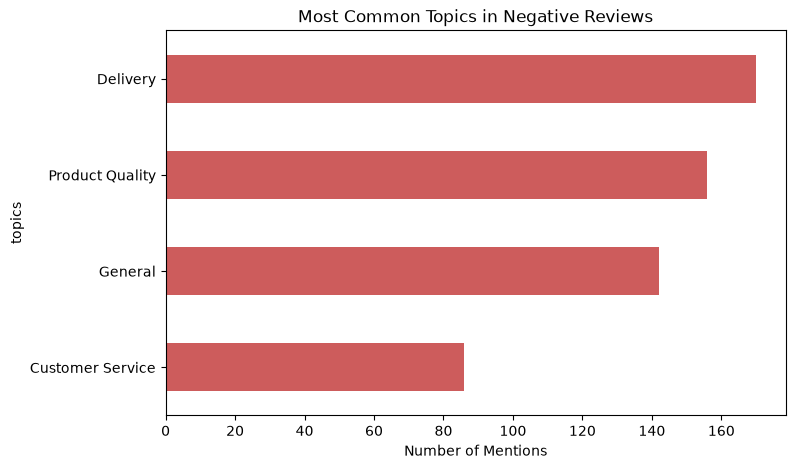

In [3]:
negative = sentiment[sentiment["sentiment_label"] == "Negative"]
topic_counts = negative["topics"].str.split(", ").explode().value_counts()

plt.figure(figsize=(8,5))
topic_counts.plot(kind="barh", color="indianred")
plt.title("Most Common Topics in Negative Reviews")
plt.xlabel("Number of Mentions")
plt.gca().invert_yaxis()
plt.show()

## 4. Sentiment vs churn status
**Business question:** Is declining sentiment an early warning sign of churn?

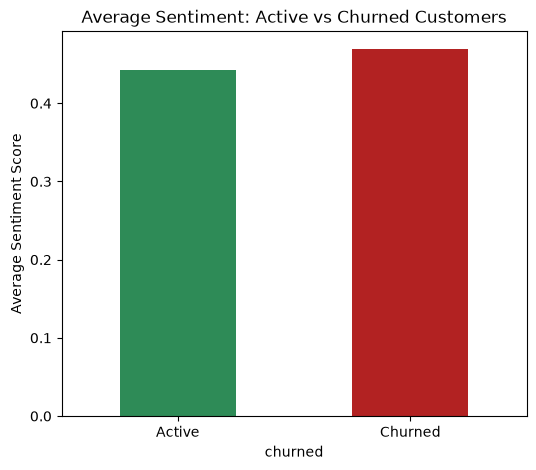

In [4]:
plt.figure(figsize=(6,5))
link.groupby("churned")["avg_sentiment_score"].mean().plot(
    kind="bar", color=["seagreen","firebrick"]
)
plt.xticks([0,1], ["Active", "Churned"], rotation=0)
plt.title("Average Sentiment: Active vs Churned Customers")
plt.ylabel("Average Sentiment Score")
plt.show()

## 5. Sentiment vs monetary value
**Business question:** Do happier customers actually spend more?

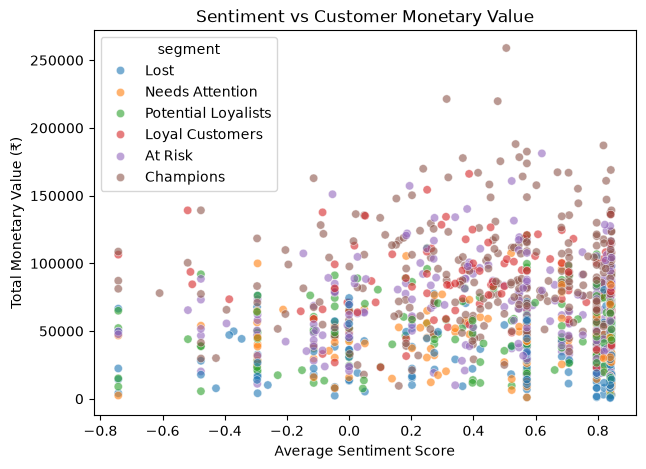

In [5]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=link, x="avg_sentiment_score", y="monetary", hue="segment", alpha=0.6)
plt.title("Sentiment vs Customer Monetary Value")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Total Monetary Value (\u20b9)")
plt.show()

## Summary of findings

_Write 3-4 sentences based on what you actually observed:_
- Did sentiment align with star ratings as expected?
- What's the #1 complaint topic worth escalating to operations?
- Is there a visible gap in sentiment between active and churned customers?